<a href="https://colab.research.google.com/github/pOrtal0220/Cotton-Prediction-Model/blob/main/Cotton%20Disease%20Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
from torchvision.transforms import ToTensor
from torchvision.utils import make_grid
from torch.utils.data.dataloader import DataLoader
from torchvision.datasets import ImageFolder
import torchvision.transforms as T
import torchvision.models as models
%matplotlib inline

In [ ]:
data_dir = "./Cotton Disease"
print(os.listdir(data_dir))

['.ipynb_checkpoints', 'Cotton Disease Prediction.ipynb', 'test', 'train', 'val']


In [ ]:
classes = os.listdir(data_dir + "./train")
print(classes)

['diseased cotton leaf', 'diseased cotton plant', 'fresh cotton leaf', 'fresh cotton plant']


In [ ]:
diseased_cotton_leaf = os.listdir(data_dir + "./train/diseased cotton leaf")
print(diseased_cotton_leaf[:5])
print(len(diseased_cotton_leaf))

['dis_leaf (1)_iaip.jpg', 'dis_leaf (10)_iaip.jpg', 'dis_leaf (101)_iaip.jpg', 'dis_leaf (102)_iaip.jpg', 'dis_leaf (103)_iaip.jpg']
288


In [ ]:
for i in  classes:
    result = os.listdir(data_dir + "./train/" + i)
    print(f"Number of images in {i} = {len(result)}")

Number of images in diseased cotton leaf = 288
Number of images in diseased cotton plant = 815
Number of images in fresh cotton leaf = 427
Number of images in fresh cotton plant = 421


In [ ]:
image_size = 224
batch_size = 32
stats = ((0.485, 0.456, 0.406),
         (0.229, 0.224, 0.225))

In [ ]:
train_ds = ImageFolder(data_dir + "/train", transform = T.Compose([
    T.Resize(image_size),
    T.CenterCrop(image_size),
    T.ToTensor(), T.Normalize(*stats)]))
val_ds = ImageFolder(data_dir + "/val", transform = T.Compose([
    T.Resize(image_size),
    T.CenterCrop(image_size),
    T.ToTensor(), T.Normalize(*stats)]))

In [ ]:
train_dl = DataLoader(train_ds, batch_size, shuffle=True, num_workers=3, pin_memory=True)
val_dl = DataLoader(val_ds, batch_size*2, num_workers=4, pin_memory=True)

In [ ]:
def denorm(img_tensors):
    return img_tensors * stats[1][0] + stats[0][0]

def show_images(images, nmax=64):
    fig, ax = plt.subplots(figsize=(8,8))
    ax.set_xticks([]); ax.set_yticks([])
    ax.imshow(make_grid(denorm(images.detach()[:nmax]), nrow=8).permute(1,2,0))

def show_batch(dl, nmax=64):
    for images, _ in dl:
        show_images(images, nmax)
        break

C:\Users\KAVYA\PYTHON\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.08956].


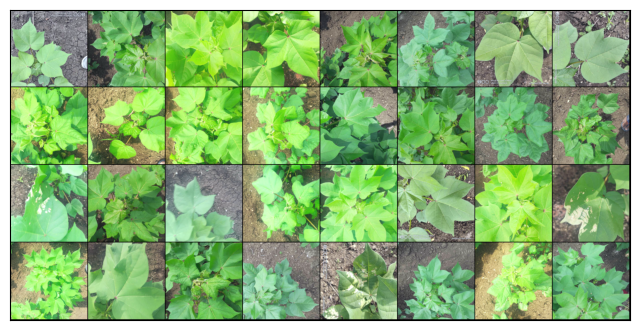

In [ ]:
show_batch(train_dl)
torch.cuda.empty_cache()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.08956].


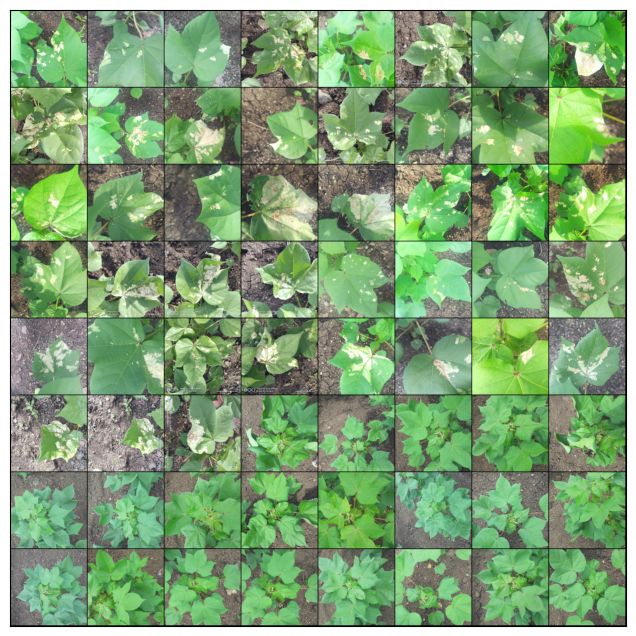

In [ ]:
show_batch(val_dl)
torch.cuda.empty_cache()

In [ ]:
class ImageClassificationBase(nn.Module):
    def training_step(self, batch):
        images, labels = batch
        out = self(images)
        loss = F.cross_entropy(out, labels)
        return loss

    def validation_step(self, batch):
        images, labels = batch
        out = self(images)
        loss = F.cross_entropy(out, labels)
        acc = accuracy(out, labels)
        return {'val_loss' : loss.detach(), 'val_acc' : acc}

    def validation_epoch_end(self,outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean()
        return {'val_loss' : epoch_loss.item(), 'val_acc' : epoch_acc.item()}

    def epoch_end(self, epoch, result):
        print("Epoch [{}], train_loss: {:.4f}, val_loss: {:.4f}, val_acc: {:.4f}".format(
            epoch, result['train_loss'], result['val_loss'], result['val_acc']))

def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds == labels).item() / len(preds))

In [ ]:
class TransferLearningModel(ImageClassificationBase):
    def __init__(self):
        super().__init__()
        self.network = models.resnet50(pretrained=True)


        for param in self.network.parameters():
            param.requires_grad = False

        num_ftrs = self.network.fc.in_features
        self.network.fc = nn.Linear(num_ftrs, 4)

    def forward(self, xb):
        return self.network(xb)

In [ ]:
model = TransferLearningModel()
model

C:\Users\KAVYA\PYTHON\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\KAVYA\PYTHON\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


TransferLearningModel(
  (network): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequenti

In [ ]:
for images, labels in train_dl:
    print('images.shape:', images.shape)
    out = model(images)
    print('out.shape:', out.shape)
    print('out[0]:', out[0])
    break

images.shape: torch.Size([32, 3, 224, 224])
out.shape: torch.Size([32, 4])
out[0]: tensor([ 0.3116,  0.2954,  0.0660, -0.5461], grad_fn=<SelectBackward0>)


In [ ]:
def get_default_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')

def to_device(data, device):
    if isinstance(data, (list,tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

class DeviceDataLoader():
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device

    def __iter__(self):
        for b in self.dl:
            yield to_device(b, self.device)

    def __len__(self):
        return len(self.dl)

In [ ]:
device = get_default_device()
device

device(type='cpu')

In [ ]:
train_dl = DeviceDataLoader(train_dl, device)
val_dl = DeviceDataLoader(val_dl, device)
to_device(model, device);

In [ ]:
@torch.no_grad()
def evaluate(model, val_loader):
    model.eval()
    outputs = [model.validation_step(batch) for batch in val_loader]
    return model.validation_epoch_end(outputs)

def fit(epochs, lr, model, train_loader, val_loader, opt_func=torch.optim.SGD):
    history = []
    optimizer = opt_func(model.parameters(), lr)
    for epoch in range(epochs):
        model.train()
        train_losses = []
        for batch in train_loader:
            loss = model.training_step(batch)
            train_losses.append(loss)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        result = evaluate(model, val_loader)
        result['train_loss'] = torch.stack(train_losses).mean().item()
        model.epoch_end(epoch, result)
        history.append(result)

    return history

In [ ]:
model = to_device(TransferLearningModel(), device)

In [ ]:
evaluate(model,val_dl)

{'val_loss': 1.439163088798523, 'val_acc': 0.20760758221149445}

In [ ]:
num_epochs = 10
opt_func = torch.optim.Adam
lr = 0.0008

In [ ]:
%%time
history = fit(num_epochs, lr, model, train_dl, val_dl, opt_func)

Epoch [0], train_loss: 0.7500, val_loss: 0.4046, val_acc: 0.9043
Epoch [1], train_loss: 0.3572, val_loss: 0.2976, val_acc: 0.9086
Epoch [2], train_loss: 0.2522, val_loss: 0.2194, val_acc: 0.9246
Epoch [3], train_loss: 0.2168, val_loss: 0.1804, val_acc: 0.9647
Epoch [4], train_loss: 0.1945, val_loss: 0.1714, val_acc: 0.9531
Epoch [5], train_loss: 0.1844, val_loss: 0.2150, val_acc: 0.9205
Epoch [6], train_loss: 0.1504, val_loss: 0.1666, val_acc: 0.9287
Epoch [7], train_loss: 0.1563, val_loss: 0.1270, val_acc: 0.9566
Epoch [8], train_loss: 0.1235, val_loss: 0.1370, val_acc: 0.9488
Epoch [9], train_loss: 0.1404, val_loss: 0.1323, val_acc: 0.9488
CPU times: total: 5h 5min 27s
Wall time: 53min 3s


In [ ]:
plot_losses(history_10_epoch)
plot_accuracies(history_10_epoch)

NameError: name 'plot_losses' is not defined

In [ ]:
print("Starting 6-epoch training run to save the best model...")
model_to_save = to_device(TransferLearningModel(), device)
history_6_epoch = fit(6, 0.001, model_to_save, train_dl, val_dl)
torch.save(model_to_save.state_dict(), 'cotton-disease-resnet50-best.pth')
print("Model saved as 'cotton-disease-resnet50-best.pth'")

Starting 6-epoch training run to save the best model...


In [ ]:
def plot_accuracies(history):
    accuracies = [x['val_acc'] for x in history]
    plt.plot(accuracies, '-x')
    plt.xlabel('epoch')
    plt.ylabel('accuracy')
    plt.title('Accuracy vs. No. of epochs');

In [ ]:
plot_accuracies(history)

In [ ]:
def plot_losses(history):
    train_losses = [x.get('train_loss') for x in history]
    val_losses = [x['val_loss'] for x in history]
    plt.plot(train_losses, '-bx')
    plt.plot(val_losses, '-rx')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.legend(['Training', 'Validation'])
    plt.title('Loss vs. No. of epochs');

In [ ]:
plot_losses(history)

In [ ]:
test_dataset = ImageFolder(data_dir + "/test", transform=T.Compose([
    T.Resize(image_size),
    T.CenterCrop(image_size),
    T.ToTensor(),T.Normalize(*stats)]))

In [ ]:
def predict_image(img, model):
    xb = to_device(img.unsqueeze(0), device)
    yb = model(xb)
    _, preds  = torch.max(yb, dim=1)
    return dataset.classes[preds[0].item()]

In [ ]:
dataset = ImageFolder(data_dir+'/train', transform=ToTensor())

In [ ]:
torch.save(model.state_dict(), 'modelCottonDemo.pth')

In [ ]:
test_dataset1 = ImageFolder(data_dir+'/test', transform=ToTensor())
img, label = test_dataset[0]
plt.imshow(denorm(img.permute(1, 2, 0)))
print('Label:', dataset.classes[label], ', Predicted:', predict_image(img, model))

In [ ]:
torch.cuda.empty_cache()

In [ ]:
import os
print(os.getcwd())   # shows the working directory
print(os.listdir())  # lists all files in that folder